In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
import os
import glob
import xarray as xr

DATA_DIR = "/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data"

nc_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))

print("=" * 70)
print("DATASET LOADING SUMMARY")
print("=" * 70)

print(f"Dataset path       : {DATA_DIR}")
print(f"Total .nc files    : {len(nc_files)}")

print("\nFirst 5 files:")
for f in nc_files[:5]:
    print("•", os.path.basename(f))


DATASET LOADING SUMMARY
Dataset path       : /kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data
Total .nc files    : 3410

First 5 files:
• chimanimani_s2_1000.nc
• chimanimani_s2_1001.nc
• chimanimani_s2_1002.nc
• chimanimani_s2_1003.nc
• chimanimani_s2_1004.nc


In [4]:
sample_path = nc_files[0]
sample_ds = xr.open_dataset(sample_path)

print("=" * 70)
print("SAMPLE FILE INSPECTION")
print("=" * 70)

print(f"Sample file: {os.path.basename(sample_path)}")

print("\nAvailable variables:")
for var in sample_ds.variables:
    print("•", var)

print("\nDataset dimensions:")
print(sample_ds.dims)

sample_ds.close()

SAMPLE FILE INSPECTION
Sample file: chimanimani_s2_1000.nc

Available variables:
• B02
• B03
• B04
• B05
• B06
• B07
• B08
• B8A
• B11
• B12
• SCL
• MASK
• DEM
• spatial_ref
• x
• y
• time

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'time': 15, 'x': 128, 'y': 128})


In [5]:
import os
import random
import numpy as np
import torch

# ============================================================
# STAGE 1 CONFIGURATION
# ============================================================

CFG = {
    # -------------------------
    # Dataset / Path Settings
    # -------------------------
    "data_dir": DATA_DIR,
    "checkpoint_dir": "./checkpoints",
    "stage1_checkpoint": "stage1_best.pth",

    # -------------------------
    # Reproducibility
    # -------------------------
    "seed": 42,

    # -------------------------
    # Stage 1 Input Settings
    # -------------------------
    "num_timestamps": 15,
    "num_pairs": 14,
    "num_features": 41,

    # -------------------------
    # Stage 1 Model Settings
    # -------------------------
    "s1_hidden_dim": 128,
    "s1_num_heads": 4,
    "s1_num_layers": 3,
    "s1_dropout": 0.3,

    # -------------------------
    # Stage 1 Training Settings
    # -------------------------
    "s1_epochs": 10,
    "s1_batch": 4,
    "s1_lr": 3e-4,
    "s1_weight_decay": 1e-4,
    "s1_grad_clip": 1.0,

    # -------------------------
    # Scheduler / Warmup
    # -------------------------
    "s1_warmup": 10,

    # -------------------------
    # Loss Weights
    # -------------------------
    "s1_pair_weight": 0.6,
    "s1_conf_weight": 0.1,
    "s1_curriculum_ep": 30,

    # -------------------------
    # Threshold Search
    # -------------------------
    "threshold_start": 0.20,
    "threshold_end": 0.80,
    "threshold_step": 0.02,
}

# ============================================================
# DEVICE SETUP
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# SEED SETUP
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])

# ============================================================
# CHECKPOINT SETUP
# ============================================================

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
CKPT1 = os.path.join(CFG["checkpoint_dir"], CFG["stage1_checkpoint"])

# ============================================================
# CONFIG SUMMARY
# ============================================================

print("=" * 70)
print("STAGE 1 TRAINING SETUP")
print("=" * 70)
print(f"Device              : {DEVICE}")
print(f"Data Directory      : {CFG['data_dir']}")
print(f"Checkpoint Path     : {CKPT1}")
print(f"Epochs              : {CFG['s1_epochs']}")
print(f"Batch Size          : {CFG['s1_batch']}")
print(f"Learning Rate       : {CFG['s1_lr']}")
print(f"Weight Decay        : {CFG['s1_weight_decay']}")
print(f"Hidden Dimension    : {CFG['s1_hidden_dim']}")
print(f"Transformer Heads   : {CFG['s1_num_heads']}")
print(f"Transformer Layers  : {CFG['s1_num_layers']}")
print(f"Dropout             : {CFG['s1_dropout']}")
print(f"Pair Loss Weight    : {CFG['s1_pair_weight']}")
print(f"Confidence Weight   : {CFG['s1_conf_weight']}")
print("=" * 70)

STAGE 1 TRAINING SETUP
Device              : cuda
Data Directory      : /kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data
Checkpoint Path     : ./checkpoints/stage1_best.pth
Epochs              : 10
Batch Size          : 4
Learning Rate       : 0.0003
Weight Decay        : 0.0001
Hidden Dimension    : 128
Transformer Heads   : 4
Transformer Layers  : 3
Dropout             : 0.3
Pair Loss Weight    : 0.6
Confidence Weight   : 0.1


In [6]:
from scipy.ndimage import sobel
import torch
import torch.nn.functional as F

BANDS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
BAND_IDX = {b: i for i, b in enumerate(BANDS)}

def load_nc_file(path):
    ds = xr.open_dataset(path)

    bands = np.stack(
        [ds[b].values.astype(np.float32) for b in BANDS],
        axis=1
    ) / 10000.0

    bands = np.clip(bands, 0, 1)

    scl = ds["SCL"].values.astype(np.int16)
    mask = ds["MASK"].values.astype(np.uint8)

    dem_raw = ds["DEM"].values.astype(np.float32)
    dem = dem_raw[0] if dem_raw.ndim == 3 else dem_raw

    meta = dict(ds.attrs)
    ds.close()

    return {
        "bands": bands,
        "scl": scl,
        "mask": mask,
        "dem": dem,
        "meta": meta
    }


def get_cloud_mask(scl):
    return np.isin(scl, [3, 8, 9, 10])


def compute_dem_slope(dem):
    dx = sobel(dem, axis=1)
    dy = sobel(dem, axis=0)
    slope = np.sqrt(dx**2 + dy**2)
    return float(slope.mean()), float(slope.std())


def sliding_window_max(heatmap, window_size=7):
    h = torch.tensor(heatmap).unsqueeze(1)
    pad = window_size // 2
    pooled = F.max_pool2d(h, kernel_size=window_size, stride=1, padding=pad)
    return pooled.squeeze(1).mean(dim=(-1, -2)).numpy()


def permanence_check(bands, candidate_t, n_post=3):
    T = bands.shape[0]

    if candidate_t == 0 or candidate_t >= T - 1:
        return 0.0

    pre_b04 = bands[candidate_t - 1, BAND_IDX["B04"]]
    pre_b08 = bands[candidate_t - 1, BAND_IDX["B08"]]

    n_check = min(n_post, T - candidate_t - 1)

    if n_check == 0:
        return 1.0

    persistent = 0

    for k in range(1, n_check + 1):
        if (
            np.mean(bands[candidate_t + k, BAND_IDX["B04"]] - pre_b04) > 0
            and np.mean(bands[candidate_t + k, BAND_IDX["B08"]] - pre_b08) < 0
        ):
            persistent += 1

    return persistent / n_check


TIME_ENC = np.stack([
    np.sin(2 * np.pi * np.arange(14, dtype=np.float32) / 14),
    np.cos(2 * np.pi * np.arange(14, dtype=np.float32) / 14)
], axis=1)

In [7]:
from tqdm import tqdm

In [10]:
# ============================================================
# STAGE 1 CATALOGUE BUILDING
# ============================================================

catalog = []

for path in tqdm(nc_files, desc="Building catalogue"):
    try:
        ds = xr.open_dataset(path)

        mask = ds["MASK"].values
        landslide_label = int(mask.sum() > 0)

        catalog.append({
            "path": path,
            "file": os.path.basename(path),
            "label": landslide_label
        })

        ds.close()

    except Exception as e:
        print("Skipped:", os.path.basename(path), "| Error:", e)

catalog_df = pd.DataFrame(catalog)

print("=" * 70)
print("CATALOGUE SUMMARY")
print("=" * 70)
print("Total files in catalogue:", len(catalog_df))
print("\nLabel distribution:")
print(catalog_df["label"].value_counts())

catalog_df.head()
# ============================================================
# DEVICE CHECK
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "=" * 70)
print("HARDWARE INFORMATION")
print("=" * 70)

if torch.cuda.is_available():
    print(f"Device Type : GPU")
    print(f"GPU Name    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("Device Type : CPU")

print("=" * 70)

Building catalogue: 100%|██████████| 3410/3410 [07:34<00:00,  7.50it/s]


CATALOGUE SUMMARY
Total files in catalogue: 3410

Label distribution:
label
0    1999
1    1411
Name: count, dtype: int64

HARDWARE INFORMATION
Device Type : GPU
GPU Name    : Tesla T4
CUDA Version: 12.8


In [18]:
print(type(catalog_df))

<class 'pandas.core.frame.DataFrame'>


In [19]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    catalog_df,
    test_size=0.15,
    random_state=CFG["seed"],
    stratify=catalog_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("=" * 70)
print("TRAIN / VALIDATION SPLIT SUMMARY")
print("=" * 70)
print(f"Train samples : {len(train_df)}")
print(f"Val samples   : {len(val_df)}")

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())
print("=" * 70)

TRAIN / VALIDATION SPLIT SUMMARY
Train samples : 2898
Val samples   : 512

Train label distribution:
label
0    1699
1    1199
Name: count, dtype: int64

Validation label distribution:
label
0    300
1    212
Name: count, dtype: int64


In [20]:
from torch.utils.data import Dataset

class Stage1Dataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment
        self.samples = []

        print(f"Preloading {len(self.dataframe)} files...")

        for _, row in tqdm(self.dataframe.iterrows(), total=len(self.dataframe)):
            try:
                feats, _, _, _, _ = extract_stage1_features(row["path"])

                is_ls = int(row["label"])

                # pair label kept as 0 here because current catalogue has only binary label
                pair_label = 0

                self.samples.append((
                    torch.tensor(feats, dtype=torch.float32),
                    torch.tensor(pair_label, dtype=torch.long),
                    torch.tensor(is_ls, dtype=torch.float32)
                ))

            except Exception as e:
                print("Skipped:", row["file"], "| Error:", e)

        print(f"Loaded {len(self.samples)} samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feats, pair_label, is_ls = self.samples[idx]

        if self.augment:
            if random.random() > 0.5:
                feats = feats + torch.randn_like(feats) * 0.01

        return feats, pair_label, is_ls

In [21]:
CFG["window_size"] = 7
print("window_size added:", CFG["window_size"])

window_size added: 7


In [22]:
SIGN_VEC = np.array([
    0, 0, 0, 0, 0, 0,
    -1,  # B08 decrease
    -1,  # B8A decrease
    1,   # B11 increase
    1    # B12 increase
], dtype=np.float32)

print("SIGN_VEC defined:", SIGN_VEC)

SIGN_VEC defined: [ 0.  0.  0.  0.  0.  0. -1. -1.  1.  1.]


In [23]:
def extract_stage1_features(path):
    data = load_nc_file(path)

    bands = data["bands"]
    scl = data["scl"]
    dem = data["dem"]

    clouds = get_cloud_mask(scl)
    slope_mean, slope_std = compute_dem_slope(dem)

    ndvi_all = []
    nbr_all = []
    bsi_all = []

    eps = 1e-6

    for t in range(15):
        b = bands[t]

        ndvi = (
            b[BAND_IDX["B08"]] - b[BAND_IDX["B04"]]
        ) / (
            b[BAND_IDX["B08"]] + b[BAND_IDX["B04"]] + eps
        )

        nbr = (
            b[BAND_IDX["B08"]] - b[BAND_IDX["B11"]]
        ) / (
            b[BAND_IDX["B08"]] + b[BAND_IDX["B11"]] + eps
        )

        bsi = (
            (b[BAND_IDX["B11"]] + b[BAND_IDX["B04"]])
            - (b[BAND_IDX["B08"]] + b[BAND_IDX["B02"]])
        ) / (
            (b[BAND_IDX["B11"]] + b[BAND_IDX["B04"]])
            + (b[BAND_IDX["B08"]] + b[BAND_IDX["B02"]])
            + eps
        )

        ndvi_all.append(ndvi.mean())
        nbr_all.append(nbr.mean())
        bsi_all.append(bsi.mean())

    # Change vector between consecutive timestamps
    cv = bands[1:] - bands[:-1]

    # Landslide-sign heatmap
    sign_vec = SIGN_VEC[np.newaxis, :, np.newaxis, np.newaxis]
    heatmap = np.mean(np.maximum(cv * sign_vec, 0), axis=1)

    # Sliding window score
    sw_scores = sliding_window_max(
        heatmap,
        CFG["window_size"]
    )

    # Cloud pair mask
    cloud_pair = clouds[:-1] | clouds[1:]

    features = []

    for t in range(14):
        valid = ~cloud_pair[t]
        n_valid = valid.sum()
        cloud_frac = 1.0 - float(valid.mean())

        if n_valid < 10:
            mean_cv = np.zeros(10, dtype=np.float32)
            sig = 0.0
            pre_abs = np.zeros(10, dtype=np.float32)
            post_abs = np.zeros(10, dtype=np.float32)

        else:
            mean_cv = cv[t][:, valid].mean(axis=1).astype(np.float32)

            sig = float(
                np.mean(
                    np.maximum(mean_cv * SIGN_VEC, 0)
                )
            )

            pre_abs = bands[t][:, valid].mean(axis=1).astype(np.float32)
            post_abs = bands[t + 1][:, valid].mean(axis=1).astype(np.float32)

        perm = float(
            permanence_check(
                bands,
                t + 1
            )
        )

        row = np.concatenate([
            mean_cv,
            [sig],
            [sw_scores[t]],
            [perm],
            [cloud_frac],
            [
                ndvi_all[t + 1] - ndvi_all[t],
                nbr_all[t + 1] - nbr_all[t],
                bsi_all[t + 1] - bsi_all[t]
            ],
            pre_abs,
            post_abs,
            [slope_mean, slope_std],
            TIME_ENC[t]
        ]).astype(np.float32)

        features.append(row)

    return (
        np.stack(features, axis=0),
        heatmap,
        bands,
        data["mask"],
        data["dem"]
    )


print("extract_stage1_features() defined successfully.")

extract_stage1_features() defined successfully.


In [24]:
from torch.utils.data import DataLoader, WeightedRandomSampler

print("Building Stage 1 datasets...")

train_ds1 = Stage1Dataset(train_df, augment=False)
val_ds1 = Stage1Dataset(val_df, augment=False)

is_ls_flags = [sample[2].item() for sample in train_ds1.samples]

n_pos = max(1, sum(is_ls_flags))
n_neg = max(1, len(is_ls_flags) - n_pos)

sample_weights = [
    1.0 / n_pos if flag == 1 else 1.0 / n_neg
    for flag in is_ls_flags
]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dl1 = DataLoader(
    train_ds1,
    batch_size=CFG["s1_batch"],
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dl1 = DataLoader(
    val_ds1,
    batch_size=CFG["s1_batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("STAGE 1 DATALOADER SUMMARY")
print("=" * 70)
print(f"Train dataset size : {len(train_ds1)}")
print(f"Val dataset size   : {len(val_ds1)}")
print(f"Train batches      : {len(train_dl1)}")
print(f"Val batches        : {len(val_dl1)}")
print(f"Positive samples   : {int(n_pos)}")
print(f"Negative samples   : {int(n_neg)}")
print(f"Batch size         : {CFG['s1_batch']}")
print("=" * 70)

Building Stage 1 datasets...
Preloading 2898 files...


100%|██████████| 2898/2898 [12:35<00:00,  3.84it/s]


Loaded 2898 samples.
Preloading 512 files...


100%|██████████| 512/512 [02:09<00:00,  3.95it/s]

Loaded 512 samples.
STAGE 1 DATALOADER SUMMARY
Train dataset size : 2898
Val dataset size   : 512
Train batches      : 725
Val batches        : 128
Positive samples   : 1199
Negative samples   : 1699
Batch size         : 4


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [26]:
CFG["s1_focal_alpha"] = 0.75
CFG["s1_focal_gamma"] = 2.0
CFG["s1_label_smooth"] = 0.1

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [28]:
# ============================================================
# MISSING STAGE 1 LOSS CONFIGS
# ============================================================

CFG["s1_focal_alpha"] = 0.75
CFG["s1_focal_gamma"] = 2.0
CFG["s1_label_smooth"] = 0.1

print("Stage 1 loss config added:")
print("s1_focal_alpha  :", CFG["s1_focal_alpha"])
print("s1_focal_gamma  :", CFG["s1_focal_gamma"])
print("s1_label_smooth :", CFG["s1_label_smooth"])

Stage 1 loss config added:
s1_focal_alpha  : 0.75
s1_focal_gamma  : 2.0
s1_label_smooth : 0.1


In [29]:
class Stage1Model(nn.Module):
    def __init__(
        self,
        feat_dim=41,
        hidden=256,
        n_heads=8,
        n_layers=4,
        ffn_dim=512,
        dropout=0.3,
        n_pairs=14
    ):
        super().__init__()

        self.pair_encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2)
        )

        self.pos_embed = nn.Parameter(
            torch.randn(1, n_pairs, hidden) * 0.02
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout / 2,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )

        self.ls_attn = nn.Linear(hidden, 1)

        self.ls_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

        self.pair_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        enc = self.pair_encoder(x) + self.pos_embed
        ctx = self.transformer(enc)

        pair_logits = self.pair_head(ctx).squeeze(-1)

        attn_w = torch.softmax(self.ls_attn(ctx), dim=1)
        pooled = (attn_w * ctx).sum(dim=1)

        ls_logit = self.ls_head(pooled).squeeze(-1)
        conf_logit = self.conf_head(pooled).squeeze(-1)

        return ls_logit, pair_logits, conf_logit


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        prob = torch.sigmoid(logits)
        pt = torch.where(targets == 1, prob, 1 - prob)

        at = torch.where(
            targets == 1,
            torch.full_like(pt, self.alpha),
            torch.full_like(pt, 1 - self.alpha)
        )

        loss = at * (1 - pt) ** self.gamma * bce
        return loss.mean()


class LabelSmoothCE(nn.Module):
    def __init__(self, n=14, s=0.1):
        super().__init__()
        self.n = n
        self.s = s

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        smooth_value = self.s / (self.n - 1)

        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, smooth_value)
            smooth_targets.scatter_(
                1,
                targets.unsqueeze(1),
                1.0 - self.s
            )

        return -(smooth_targets * log_probs).sum(dim=-1).mean()


class ConfLoss(nn.Module):
    def forward(self, conf_logits, pair_logits, labels):
        confidence_target = (
            pair_logits.argmax(dim=1) == labels
        ).float()

        return F.binary_cross_entropy_with_logits(
            conf_logits,
            confidence_target
        )


focal_ls = FocalLoss(
    alpha=CFG["s1_focal_alpha"],
    gamma=CFG["s1_focal_gamma"]
).to(DEVICE)

ce_pair = LabelSmoothCE(
    n=14,
    s=CFG["s1_label_smooth"]
).to(DEVICE)

conf_loss = ConfLoss().to(DEVICE)

print("=" * 70)
print("STAGE 1 MODEL DEFINED")
print("=" * 70)

n_params = sum(
    p.numel()
    for p in Stage1Model().parameters()
    if p.requires_grad
)

print(f"Stage1Model trainable parameters: {n_params:,}")
print("=" * 70)

STAGE 1 MODEL DEFINED
Stage1Model trainable parameters: 2,247,620


In [30]:
class Stage1ModelRoPE(nn.Module):
    def __init__(
        self,
        feat_dim=41,
        hidden=256,
        n_heads=8,
        n_layers=4,
        ffn_dim=512,
        dropout=0.3,
        n_pairs=14
    ):
        super().__init__()

        self.hidden = hidden
        self.n_pairs = n_pairs

        self.pair_encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2)
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout / 2,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )

        self.ls_attn = nn.Linear(hidden, 1)

        self.ls_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

        self.pair_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

        position = torch.arange(0, n_pairs, dtype=torch.float32).unsqueeze(1)
        dim = torch.arange(0, hidden, 2, dtype=torch.float32)

        inv_freq = 1.0 / (10000 ** (dim / hidden))
        angles = position * inv_freq

        sin = torch.sin(angles).unsqueeze(0)
        cos = torch.cos(angles).unsqueeze(0)

        self.register_buffer("rope_sin", sin)
        self.register_buffer("rope_cos", cos)

    def apply_rope(self, x):
        x_even = x[:, :, 0::2]
        x_odd = x[:, :, 1::2]

        x_rot_even = x_even * self.rope_cos - x_odd * self.rope_sin
        x_rot_odd = x_even * self.rope_sin + x_odd * self.rope_cos

        x_rot = torch.zeros_like(x)
        x_rot[:, :, 0::2] = x_rot_even
        x_rot[:, :, 1::2] = x_rot_odd

        return x_rot

    def forward(self, x):
        enc = self.pair_encoder(x)
        enc = self.apply_rope(enc)

        ctx = self.transformer(enc)

        pair_logits = self.pair_head(ctx).squeeze(-1)

        attn_w = torch.softmax(self.ls_attn(ctx), dim=1)
        pooled = (attn_w * ctx).sum(dim=1)

        ls_logit = self.ls_head(pooled).squeeze(-1)
        conf_logit = self.conf_head(pooled).squeeze(-1)

        return ls_logit, pair_logits, conf_logit


print("=" * 70)
print("EXPERIMENT 4 MODEL DEFINED")
print("=" * 70)

n_params_exp4 = sum(
    p.numel()
    for p in Stage1ModelRoPE().parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params_exp4:,}")
print("Positional Encoding : RoPE-style rotary temporal encoding")
print("=" * 70)

EXPERIMENT 4 MODEL DEFINED
Trainable parameters: 2,244,036
Positional Encoding : RoPE-style rotary temporal encoding


In [31]:
CFG_EXP4 = CFG.copy()

CFG_EXP4["s1_epochs"] = 50
CFG_EXP4["s1_batch"] = 8
CFG_EXP4["s1_lr"] = 1e-4
CFG_EXP4["experiment_name"] = "stage1_exp4_rope"

CKPT_EXP4 = os.path.join(
    CFG_EXP4["checkpoint_dir"],
    "stage1_exp4_rope_best.pth"
)

train_dl1_exp4 = DataLoader(
    train_ds1,
    batch_size=CFG_EXP4["s1_batch"],
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dl1_exp4 = DataLoader(
    val_ds1,
    batch_size=CFG_EXP4["s1_batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("EXPERIMENT 4 READY")
print("=" * 70)
print("Model      : RoPE-style Positional Encoding")
print("Epochs     :", CFG_EXP4["s1_epochs"])
print("Batch Size :", CFG_EXP4["s1_batch"])
print("LR         :", CFG_EXP4["s1_lr"])
print("Checkpoint :", CKPT_EXP4)
print("=" * 70)

EXPERIMENT 4 READY
Model      : RoPE-style Positional Encoding
Epochs     : 50
Batch Size : 8
LR         : 0.0001
Checkpoint : ./checkpoints/stage1_exp4_rope_best.pth


In [32]:
# ============================================================
# EXPERIMENT 4 SETTINGS - ROPE-STYLE POSITIONAL ENCODING.
# ============================================================

CFG_EXP4 = CFG.copy()

CFG_EXP4["s1_epochs"] = 50
CFG_EXP4["s1_batch"] = 8
CFG_EXP4["s1_lr"] = 1e-4

CKPT_EXP4 = os.path.join(
    CFG_EXP4["checkpoint_dir"],
    "stage1_exp4_rope_best.pth"
)

print("=" * 100)
print("STAGE 1 TRAINING STARTED - EXPERIMENT 4")
print("Change: Sinusoidal Positional Encoding -> RoPE-style Rotary Encoding")
print("=" * 100)

s1_model_exp4 = Stage1ModelRoPE().to(DEVICE)

optimizer_exp4 = optim.AdamW(
    s1_model_exp4.parameters(),
    lr=CFG_EXP4["s1_lr"],
    weight_decay=CFG_EXP4["s1_weight_decay"]
)

def lr_lambda_exp4(epoch):
    if epoch < CFG_EXP4["s1_warmup"]:
        return (epoch + 1) / CFG_EXP4["s1_warmup"]

    progress = (
        epoch - CFG_EXP4["s1_warmup"]
    ) / max(1, CFG_EXP4["s1_epochs"] - CFG_EXP4["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))

scheduler_exp4 = optim.lr_scheduler.LambdaLR(
    optimizer_exp4,
    lr_lambda_exp4
)

history4 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_exp4 = 0.0
best_thresh_exp4 = 0.5

print(f"Parameters: {sum(p.numel() for p in s1_model_exp4.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG_EXP4['s1_epochs']}")
print(f"Batch     : {CFG_EXP4['s1_batch']}")
print(f"Checkpoint: {CKPT_EXP4}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG_EXP4["s1_epochs"] + 1):

    s1_model_exp4.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG_EXP4["s1_pair_weight"],
            CFG_EXP4["s1_pair_weight"]
            * (epoch - CFG_EXP4["s1_curriculum_ep"])
            / max(1, CFG_EXP4["s1_epochs"] - CFG_EXP4["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1_exp4:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model_exp4(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + CFG_EXP4["s1_conf_weight"] * loss_conf

        optimizer_exp4.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model_exp4.parameters(),
            CFG_EXP4["s1_grad_clip"]
        )

        optimizer_exp4.step()

        total_loss += loss.item()
        n_batches += 1

    s1_model_exp4.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1_exp4:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model_exp4(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(torch.sigmoid(ls_logit).cpu().numpy())
            ls_true_all.extend(is_ls.cpu().numpy())

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(
        CFG_EXP4["threshold_start"],
        CFG_EXP4["threshold_end"],
        CFG_EXP4["threshold_step"]
    ):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history4["train_loss"].append(total_loss / max(1, n_batches))
    history4["val_loss"].append(val_metrics["loss"])

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history4[key].append(val_metrics[key])

    scheduler_exp4.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_exp4:
        best_f1_exp4 = val_metrics["f1"]
        best_thresh_exp4 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model_exp4.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history4,
                "experiment": "rope_style_rotary_encoding"
            },
            CKPT_EXP4
        )

        flag = "<- saved"

    lr = optimizer_exp4.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt_exp4 = torch.load(
    CKPT_EXP4,
    map_location=DEVICE,
    weights_only=False
)

s1_model_exp4.load_state_dict(
    ckpt_exp4["model_state"]
)

best_thresh_exp4 = ckpt_exp4["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE - EXPERIMENT 4")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_exp4:.4f}")
print(f"Best Threshold    : {best_thresh_exp4:.2f}")
print(f"Checkpoint Saved  : {CKPT_EXP4}")
print("=" * 100)

STAGE 1 TRAINING STARTED - EXPERIMENT 4
Change: Sinusoidal Positional Encoding -> RoPE-style Rotary Encoding
Parameters: 2,244,036
Device    : cuda
Epochs    : 50
Batch     : 8
Checkpoint: ./checkpoints/stage1_exp4_rope_best.pth
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0590   1.2931  0.693  0.586  0.882  0.704  0.788   0.005  0.962 2.00e-05  <- saved
   2   0.0574   1.2829  0.705  0.595  0.901  0.717  0.803   0.948  0.995 3.00e-05  <- saved
   3   0.0545   1.2738  0.691  0.575  0.976  0.724  0.812   0.981  1.000 4.00e-05  <- saved
   4   0.0519   1.2965  0.715  0.596  0.967  0.737  0.833   0.943  0.991 5.00e-05  <- saved
   5   0.0492   1.3044  0.762  0.645  0.943  0.766  0.879   0.840  0.863 6.00e-05  <- saved
   6   0.0498   1.3222  0.787  0.675  0.939  0.785  0.902   0.708  0.967 7.00e-05  <- saved
   7   0.0494   1.2806  0.824  0.740

In [36]:
print("Stage1ModelRoPE" in globals())
print("train_dl1_exp4" in globals())
print("val_dl1_exp4" in globals())

True
True
True


In [37]:
# ============================================================
# EXPERIMENT 5 - ROPE 264 EPOCH TRAINING
# ============================================================

CFG_EXP5 = CFG.copy()

CFG_EXP5["s1_epochs"] = 264
CFG_EXP5["s1_batch"] = 8
CFG_EXP5["s1_lr"] = 1e-4

CKPT_EXP5 = os.path.join(
    CFG_EXP5["checkpoint_dir"],
    "stage1_exp5_rope_264epochs_best.pth"
)

print("=" * 100)
print("STAGE 1 TRAINING STARTED - EXPERIMENT 5")
print("Model : RoPE-style Transformer")
print("Epochs: 264")
print("=" * 100)

s1_model_exp5 = Stage1ModelRoPE().to(DEVICE)

optimizer_exp5 = optim.AdamW(
    s1_model_exp5.parameters(),
    lr=CFG_EXP5["s1_lr"],
    weight_decay=CFG_EXP5["s1_weight_decay"]
)

def lr_lambda_exp5(epoch):
    if epoch < CFG_EXP5["s1_warmup"]:
        return (epoch + 1) / CFG_EXP5["s1_warmup"]

    progress = (
        epoch - CFG_EXP5["s1_warmup"]
    ) / max(1, CFG_EXP5["s1_epochs"] - CFG_EXP5["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))

scheduler_exp5 = optim.lr_scheduler.LambdaLR(
    optimizer_exp5,
    lr_lambda_exp5
)

history5 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_exp5 = 0.0
best_thresh_exp5 = 0.5

print(f"Parameters: {sum(p.numel() for p in s1_model_exp5.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG_EXP5['s1_epochs']}")
print(f"Batch     : {CFG_EXP5['s1_batch']}")
print(f"Checkpoint: {CKPT_EXP5}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)
print("-" * 100)

for epoch in range(1, CFG_EXP5["s1_epochs"] + 1):

    # -------------------------
    # Training
    # -------------------------
    s1_model_exp5.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG_EXP5["s1_pair_weight"],
            CFG_EXP5["s1_pair_weight"]
            * (epoch - CFG_EXP5["s1_curriculum_ep"])
            / max(1, CFG_EXP5["s1_epochs"] - CFG_EXP5["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1_exp4:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model_exp5(feats)

        loss_ls = focal_ls(ls_logit, is_ls)
        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = (
            loss_ls
            + pair_w * loss_pair
            + CFG_EXP5["s1_conf_weight"] * loss_conf
        )

        optimizer_exp5.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model_exp5.parameters(),
            CFG_EXP5["s1_grad_clip"]
        )

        optimizer_exp5.step()

        total_loss += loss.item()
        n_batches += 1

    # -------------------------
    # Validation
    # -------------------------
    s1_model_exp5.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1_exp4:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model_exp5(feats)

            loss_ls = focal_ls(ls_logit, is_ls)
            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(torch.sigmoid(ls_logit).cpu().numpy())
            ls_true_all.extend(is_ls.cpu().numpy())

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    # -------------------------
    # Threshold Search
    # -------------------------
    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(
        CFG_EXP5["threshold_start"],
        CFG_EXP5["threshold_end"],
        CFG_EXP5["threshold_step"]
    ):
        preds = (ls_probs > thr).astype(int)

        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history5["train_loss"].append(total_loss / max(1, n_batches))
    history5["val_loss"].append(val_metrics["loss"])

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history5[key].append(val_metrics[key])

    scheduler_exp5.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_exp5:
        best_f1_exp5 = val_metrics["f1"]
        best_thresh_exp5 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model_exp5.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history5,
                "experiment": "rope_264_epochs"
            },
            CKPT_EXP5
        )

        flag = "<- saved"

    lr = optimizer_exp5.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{history5["train_loss"][-1]:>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt_exp5 = torch.load(
    CKPT_EXP5,
    map_location=DEVICE,
    weights_only=False
)

s1_model_exp5.load_state_dict(
    ckpt_exp5["model_state"]
)

best_thresh_exp5 = ckpt_exp5["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE - EXPERIMENT 5")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_exp5:.4f}")
print(f"Best Threshold    : {best_thresh_exp5:.2f}")
print(f"Checkpoint Saved  : {CKPT_EXP5}")
print("=" * 100)

STAGE 1 TRAINING STARTED - EXPERIMENT 5
Model : RoPE-style Transformer
Epochs: 264
Parameters: 2,244,036
Device    : cuda
Epochs    : 264
Batch     : 8
Checkpoint: ./checkpoints/stage1_exp5_rope_264epochs_best.pth
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0566   1.3521  0.715  0.610  0.863  0.715  0.810   0.000  0.000 2.00e-05  <- saved
   2   0.0548   1.3349  0.707  0.597  0.901  0.718  0.805   0.066  0.066 3.00e-05  <- saved
   3   0.0509   1.3461  0.719  0.599  0.967  0.740  0.830   0.000  0.000 4.00e-05  <- saved
   4   0.0515   1.3176  0.770  0.670  0.873  0.758  0.847   0.656  0.656 5.00e-05  <- saved
   5   0.0509   1.3407  0.777  0.687  0.849  0.759  0.879   0.000  0.000 6.00e-05  <- saved
   6   0.0492   1.3365  0.770  0.658  0.925  0.769  0.876   0.000  0.000 7.00e-05  <- saved
   7   0.0481   1.3097  0.803  0.689  0.953  0.800 

In [38]:
print("Train samples :", len(train_df))
print("Val samples   :", len(val_df))

print(
    len(
        set(train_df["file"])
        &
        set(val_df["file"])
    )
)

Train samples : 2898
Val samples   : 512
0


In [39]:
print(train_df["label"].value_counts())
print()
print(val_df["label"].value_counts())

label
0    1699
1    1199
Name: count, dtype: int64

label
0    300
1    212
Name: count, dtype: int64


In [40]:
print(best_thresh_exp5)

0.35999999999999993


In [41]:
print(max(history5["f1"]))

0.9929411764705882


Train vs Validation Loss

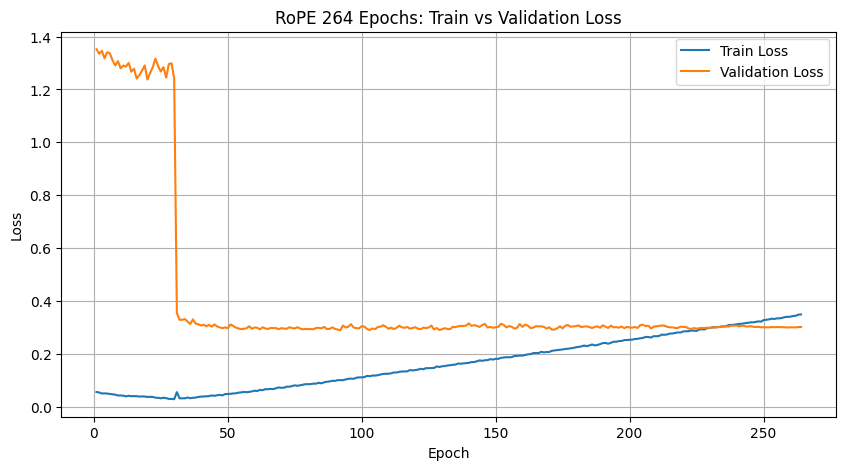

In [42]:
epochs = range(1, len(history5["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history5["train_loss"], label="Train Loss")
plt.plot(epochs, history5["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoPE 264 Epochs: Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

F1 and AUC Curve

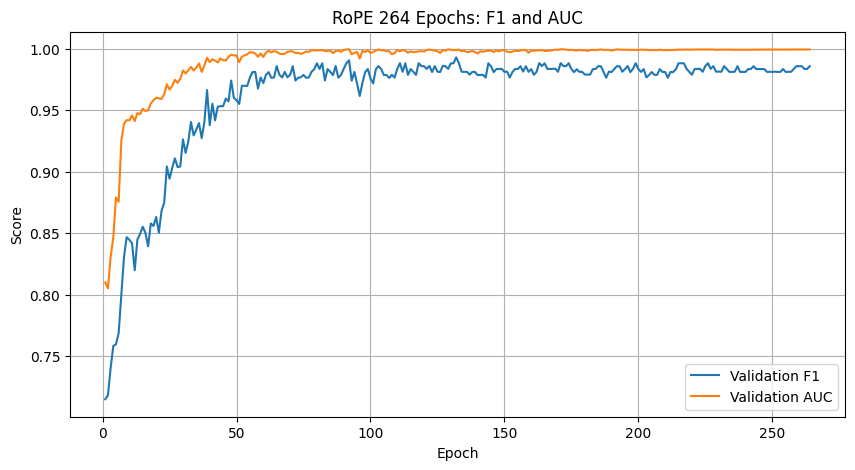

In [43]:
epochs = range(1, len(history5["f1"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history5["f1"], label="Validation F1")
plt.plot(epochs, history5["auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("RoPE 264 Epochs: F1 and AUC")
plt.legend()
plt.grid(True)
plt.show()

Precision vs Recall

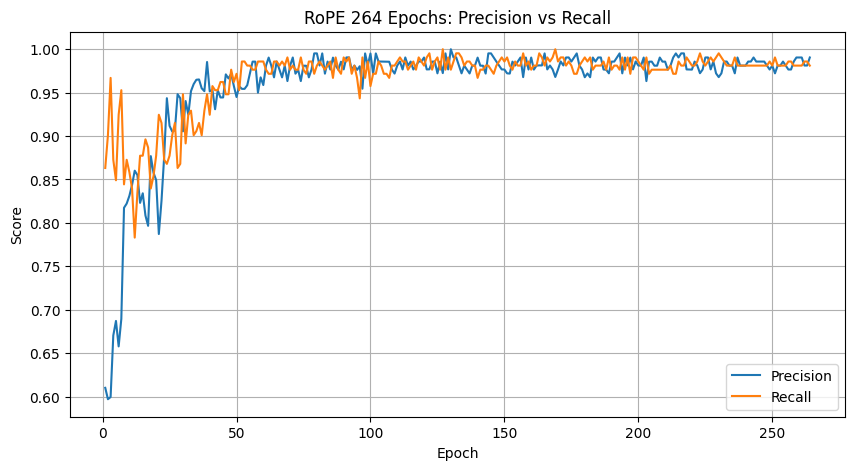

In [44]:
epochs = range(1, len(history5["precision"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history5["precision"], label="Precision")
plt.plot(epochs, history5["recall"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("RoPE 264 Epochs: Precision vs Recall")
plt.legend()
plt.grid(True)
plt.show()

Pair Prediction Performance

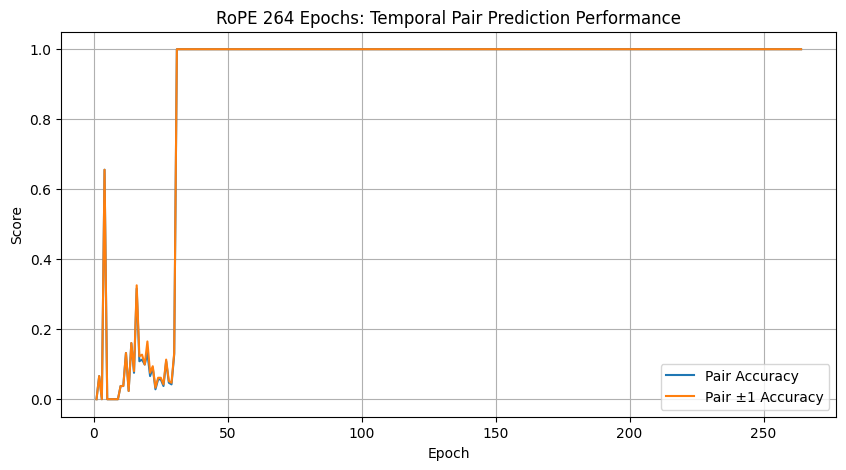

In [45]:
epochs = range(1, len(history5["pair_acc"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history5["pair_acc"], label="Pair Accuracy")
plt.plot(epochs, history5["pair_off1"], label="Pair ±1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("RoPE 264 Epochs: Temporal Pair Prediction Performance")
plt.legend()
plt.grid(True)
plt.show()

Overfitting / Underfitting Summary

In [46]:
final_train_loss = history5["train_loss"][-1]
final_val_loss = history5["val_loss"][-1]

best_f1 = max(history5["f1"])
best_f1_epoch = history5["f1"].index(best_f1) + 1

best_auc = max(history5["auc"])
best_auc_epoch = history5["auc"].index(best_auc) + 1

print("=" * 80)
print("ROPE 264 EPOCHS: OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 80)

print(f"Final Train Loss : {final_train_loss:.4f}")
print(f"Final Val Loss   : {final_val_loss:.4f}")
print(f"Best F1 Score    : {best_f1:.4f} at Epoch {best_f1_epoch}")
print(f"Best AUC Score   : {best_auc:.4f} at Epoch {best_auc_epoch}")

print("-" * 80)

if final_train_loss < final_val_loss * 0.5:
    print("Status: Possible Overfitting")
    print("Reason: Training loss is much lower than validation loss.")
elif final_train_loss > 0.8 and final_val_loss > 0.8:
    print("Status: Possible Underfitting")
    print("Reason: Both training and validation losses are high.")
else:
    print("Status: Stable / Good Fit")
    print("Reason: Training and validation losses are reasonably aligned.")

print("=" * 80)

ROPE 264 EPOCHS: OVERFITTING / UNDERFITTING ANALYSIS
Final Train Loss : 0.3498
Final Val Loss   : 0.3022
Best F1 Score    : 0.9929 at Epoch 132
Best AUC Score   : 0.9996 at Epoch 92
--------------------------------------------------------------------------------
Status: Stable / Good Fit
Reason: Training and validation losses are reasonably aligned.


In [47]:
print(sum(train_df["label"]==1))
print(sum(val_df["label"]==1))

1199
212


In [48]:
# ============================================================
# PROPER TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    catalog_df,
    test_size=0.15,
    random_state=CFG["seed"],
    stratify=catalog_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,   # 0.1765 of 85% ≈ 15% total
    random_state=CFG["seed"],
    stratify=train_val_df["label"]
)

print("=" * 70)
print("TRAIN / VAL / TEST SPLIT")
print("=" * 70)

print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Test samples :", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nVal labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

print("\nOverlap checks:")
print("Train-Val overlap :", len(set(train_df["file"]) & set(val_df["file"])))
print("Train-Test overlap:", len(set(train_df["file"]) & set(test_df["file"])))
print("Val-Test overlap  :", len(set(val_df["file"]) & set(test_df["file"])))

print("=" * 70)

TRAIN / VAL / TEST SPLIT
Train samples: 2386
Val samples  : 512
Test samples : 512

Train labels:
label
0    1399
1     987
Name: count, dtype: int64

Val labels:
label
0    300
1    212
Name: count, dtype: int64

Test labels:
label
0    300
1    212
Name: count, dtype: int64

Overlap checks:
Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0


In [50]:
print(history5.keys())

dict_keys(['train_loss', 'val_loss', 'acc', 'precision', 'recall', 'f1', 'auc', 'pair_acc', 'pair_off1'])


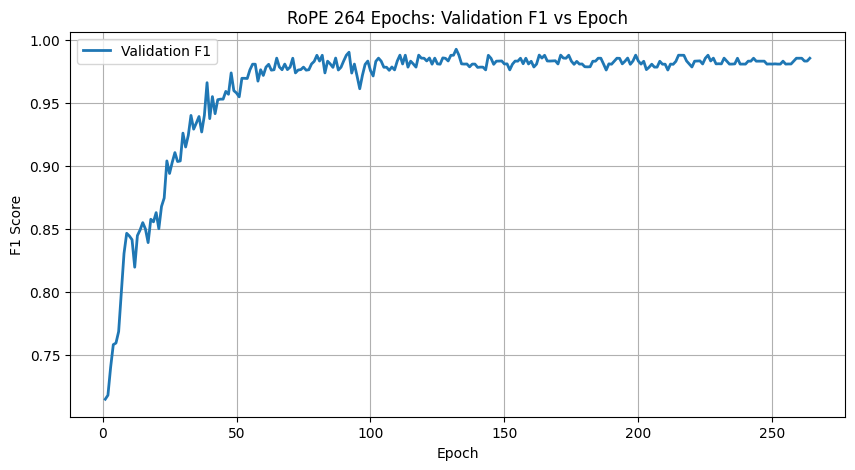

In [51]:
epochs = range(1, len(history5["f1"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, history5["f1"], label="Validation F1", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("RoPE 264 Epochs: Validation F1 vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

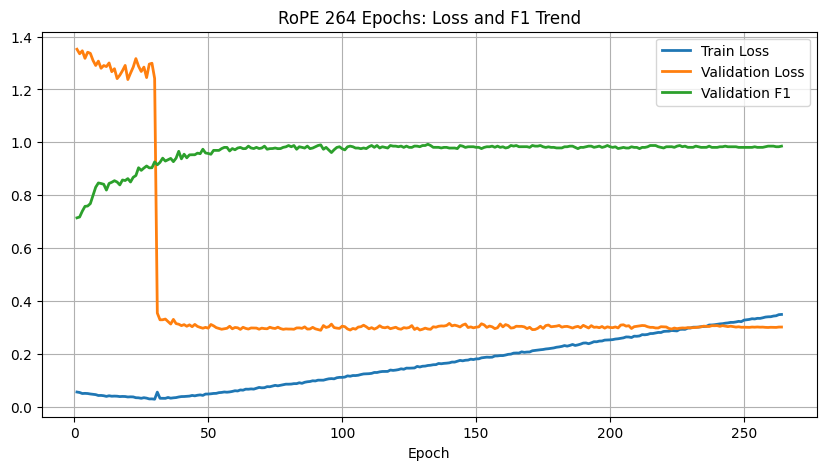

In [52]:
epochs = range(1, len(history5["f1"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, history5["train_loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, history5["val_loss"], label="Validation Loss", linewidth=2)
plt.plot(epochs, history5["f1"], label="Validation F1", linewidth=2)

plt.xlabel("Epoch")
plt.title("RoPE 264 Epochs: Loss and F1 Trend")
plt.legend()
plt.grid(True)
plt.show()

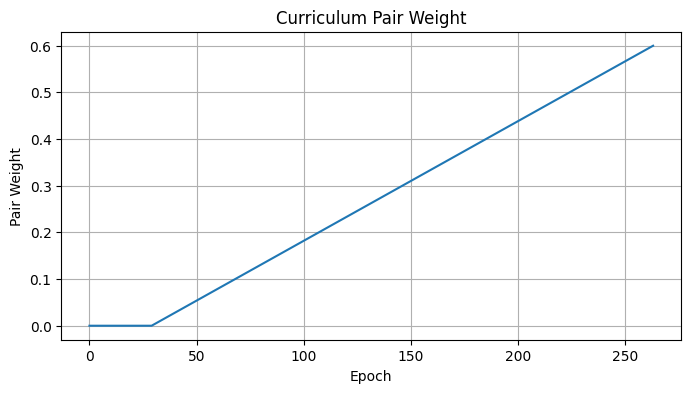

In [53]:
plt.figure(figsize=(8,4))

pair_weights = []

for epoch in range(1, 265):
    pair_w = max(
        0.0,
        min(
            CFG_EXP5["s1_pair_weight"],
            CFG_EXP5["s1_pair_weight"]
            * (epoch - CFG_EXP5["s1_curriculum_ep"])
            / max(
                1,
                CFG_EXP5["s1_epochs"]
                - CFG_EXP5["s1_curriculum_ep"]
            )
        )
    )
    pair_weights.append(pair_w)

plt.plot(pair_weights)
plt.title("Curriculum Pair Weight")
plt.xlabel("Epoch")
plt.ylabel("Pair Weight")
plt.grid(True)
plt.show()

In [54]:
print(max(history5["pair_acc"]))
print(min(history5["pair_acc"]))

print(max(history5["pair_off1"]))
print(min(history5["pair_off1"]))

1.0
0.0
1.0
0.0


In [55]:
for i in range(20):
    print(pair_true_all[i], pair_preds[i])

0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0


In [56]:
import numpy as np
import pandas as pd

pair_true_arr = np.array(pair_true_all)
pair_pred_arr = np.array(pair_preds)

print("=" * 70)
print("PAIR LABEL DISTRIBUTION")
print("=" * 70)

print("True pair labels:")
print(pd.Series(pair_true_arr).value_counts().sort_index())

print("\nPredicted pair labels:")
print(pd.Series(pair_pred_arr).value_counts().sort_index())

print("\nUnique true labels:", np.unique(pair_true_arr))
print("Unique pred labels:", np.unique(pair_pred_arr))
print("=" * 70)

PAIR LABEL DISTRIBUTION
True pair labels:
0    212
Name: count, dtype: int64

Predicted pair labels:
0    212
Name: count, dtype: int64

Unique true labels: [0]
Unique pred labels: [0]
